In [ ]:
!pip install hill-climbing

# Imports and configs

In [1]:
from hill_climbing import Climber, ClimberCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
import joblib
import glob

warnings.filterwarnings("ignore")

In [2]:
class CFG:
    train_path = "/kaggle/input/playground-series-s5e3/train.csv"
    test_path = "/kaggle/input/playground-series-s5e3/test.csv"
    sample_sub_path = "/kaggle/input/playground-series-s5e3/sample_submission.csv"

    oof_path = "/kaggle/input/hill-climbing-example-datasets/classification"
    
    target = "rainfall"
    n_folds = 10
    seed = 2100

# Loading data and OOF files

In [3]:
train = pd.read_csv(CFG.train_path, index_col="id")
X, y = train.drop(CFG.target, axis=1), train[CFG.target]

In [4]:
scores, oof_pred_probs, test_pred_probs = {}, {}, {}

In [5]:
paths = glob.glob(f"{CFG.oof_path}/*")
for path in paths:
    files = glob.glob(f"{path}/*")
    temp_oof_preds = joblib.load([file for file in files if "oof_pred_probs" in file][0])
    temp_test_preds = joblib.load([file for file in files if "test_pred_probs" in file][0])
    model_name = path.split("/")[-1]
        
    temp_scores = []        
    skf = StratifiedKFold(n_splits=CFG.n_folds, random_state=CFG.seed, shuffle=True)
    for _, val_idx in skf.split(X, y):
        temp_scores.append(roc_auc_score(y[val_idx], temp_oof_preds[val_idx]))
    
    scores[model_name] = temp_scores
    oof_pred_probs[model_name] = temp_oof_preds
    test_pred_probs[model_name] = temp_test_preds

# Hill climbing

In [6]:
X = pd.DataFrame(oof_pred_probs)
X_test = pd.DataFrame(test_pred_probs)

In [7]:
X.head()

,ridge,randomforest,xgb,gradientboosting,tabpfn,lgbm,catboost,extratrees,lgbm-goss,histgradientboosting,logisticregression,adaboost
0,0.821266,0.867503,0.926030,0.877479,0.865423,0.935042,0.898657,0.863758,0.904609,0.912727,0.909587,0.778428
1,0.885734,0.975742,0.961877,0.954630,0.983617,0.956825,0.926799,0.968880,0.950231,0.943964,0.935190,0.812482
2,0.128711,0.052198,0.107061,0.087998,0.052668,0.135400,0.152621,0.103741,0.131145,0.191842,0.049960,0.338631
3,0.994862,0.988959,0.974985,0.970845,0.995191,0.964742,0.945457,0.988565,0.962040,0.960100,0.969787,0.831931
4,0.220372,0.156352,0.088432,0.104535,0.057072,0.142069,0.165177,0.179814,0.143023,0.179690,0.064096,0.332685


In [8]:
climber = Climber(
    objective="maximize",
    eval_metric=roc_auc_score,
    allow_negative_weights=True,
    precision=0.001,
    score_decimal_places=6
)

In [9]:
climber.fit(X, y)

Configuration

   Metric:                       roc_auc_score
   Objective:                    maximize
   Precision:                    0.001
   Allow negative weights:       True
   Starting model:               best
   Number of parallel jobs:      12
   Number of models:             12


Models

   histgradientboosting   0.897811 ████████████████████████████████████████ (best)
   xgb                    0.897635 ██████████████████████████████████████
   lgbm-goss              0.897368 ████████████████████████████████████
   lgbm                   0.896853 ███████████████████████████████
   extratrees             0.896455 ████████████████████████████
   catboost               0.896321 ███████████████████████████
   gradientboosting       0.896121 █████████████████████████
   adaboost               0.895654 █████████████████████
   randomforest           0.893708 █████
   ridge                  0.893450 ███
   tabpfn                 0.893292 █
   logisticregression     0.893086 █


Ru

In [10]:
scores["climber"] = [climber.best_score] * CFG.n_folds

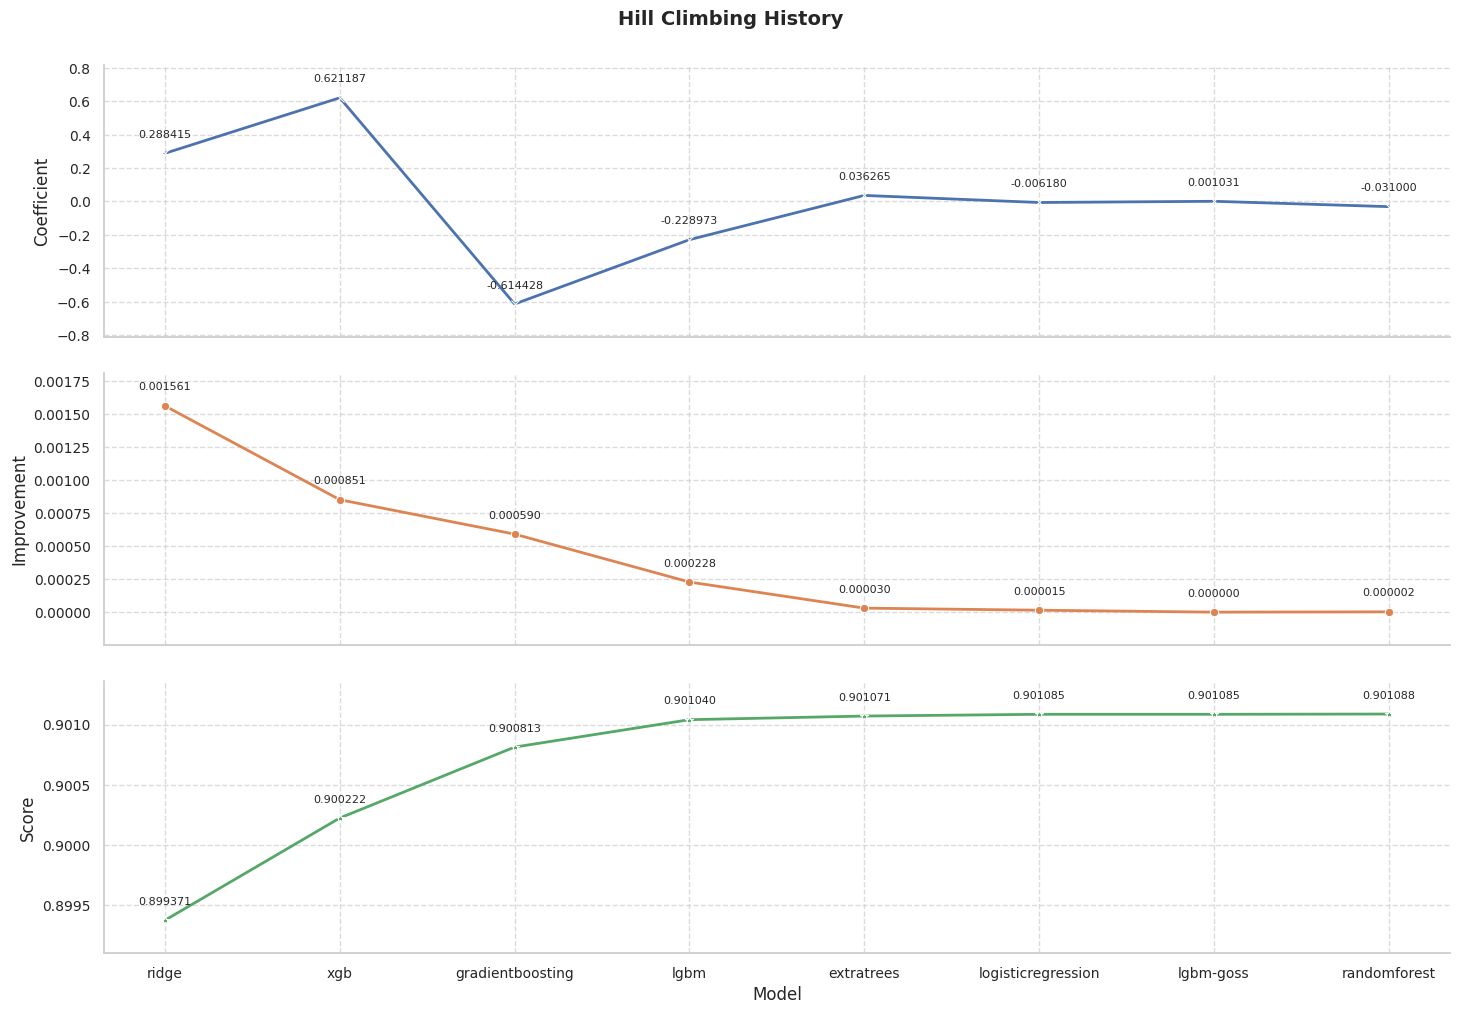

In [11]:
sns.set_style("whitegrid", {'grid.linestyle': '--'})
sns.set_context("notebook", font_scale=1.2)

def add_annotations(ax, x, y):
    for xi, yi in zip(x, y):
        ax.annotate(
            f'{yi:.6f}', (xi, yi),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            va='bottom',
            fontsize=8
        )

palette = sns.color_palette("deep")
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

sns.lineplot(x=climber.history.model[1:], y=climber.history.coef[1:], color=palette[0], marker='x', ax=ax1, linewidth=2)
add_annotations(ax1, climber.history.model[1:], climber.history.coef[1:])
ax1.set_ylabel('Coefficient', fontsize=12)
ax1.spines[['top', 'right']].set_visible(False)

sns.lineplot(x=climber.history.model[1:], y=climber.history.improvement[1:], color=palette[1], marker='o', ax=ax2, linewidth=2)
add_annotations(ax2, climber.history.model[1:], climber.history.improvement[1:])
ax2.set_ylabel('Improvement', fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)

sns.lineplot(x=climber.history.model[1:], y=climber.history.score[1:], color=palette[2], marker='*', ax=ax3, linewidth=2)
add_annotations(ax3, climber.history.model[1:], climber.history.score[1:])
ax3.set_ylabel('Score', fontsize=12)
ax3.set_xlabel('Model', fontsize=12)
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig.suptitle('Hill Climbing History', y=1.02, fontsize=14, fontweight='bold')

for ax in [ax1, ax2, ax3]:
    ax.tick_params(labelsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.xaxis.grid(True, linestyle='--', alpha=0.7)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin - (ymax-ymin)*0.1, ymax + (ymax-ymin)*0.1)

plt.show()

## Predicting on the test set

In [12]:
preds = climber.predict(X_test)
preds[:25]

array([ 0.97473725,  0.96755762,  0.87705067,  0.26833526,  0.20644456,
        0.8114628 ,  0.91803759,  0.95830086,  0.93000574,  0.70638519,
        0.96814649,  0.1956524 ,  0.96767292,  0.89700225,  0.29759274,
       -0.00506518,  0.86043231,  0.67654586,  0.18267838,  0.01704893,
        0.21172332,  0.26242902,  0.65815424,  0.98772976,  0.78464688])

# Hill climbing with cross-validation

In [13]:
climber_cv = ClimberCV(
    objective="maximize",
    eval_metric=roc_auc_score,
    allow_negative_weights=True,
    precision=0.001,
    score_decimal_places=6,
    cv=StratifiedKFold(n_splits=CFG.n_folds, random_state=CFG.seed, shuffle=True),
)

In [14]:
climber_cv.fit(X, y)

Configuration

   Metric:                       roc_auc_score
   Objective:                    maximize
   Precision:                    0.001
   Allow negative weights:       True
   Starting model:               best
   Number of parallel jobs:      12
   Number of models:             12
   Number of folds:              10


Models

   histgradientboosting   0.897811 ████████████████████████████████████████ (best)
   xgb                    0.897635 ██████████████████████████████████████
   lgbm-goss              0.897368 ████████████████████████████████████
   lgbm                   0.896853 ███████████████████████████████
   extratrees             0.896455 ████████████████████████████
   catboost               0.896321 ███████████████████████████
   gradientboosting       0.896121 █████████████████████████
   adaboost               0.895654 █████████████████████
   randomforest           0.893708 █████
   ridge                  0.893450 ███
   tabpfn                 0.893292 █
   lo

In [15]:
scores["climber-cv"] = climber_cv.fold_scores

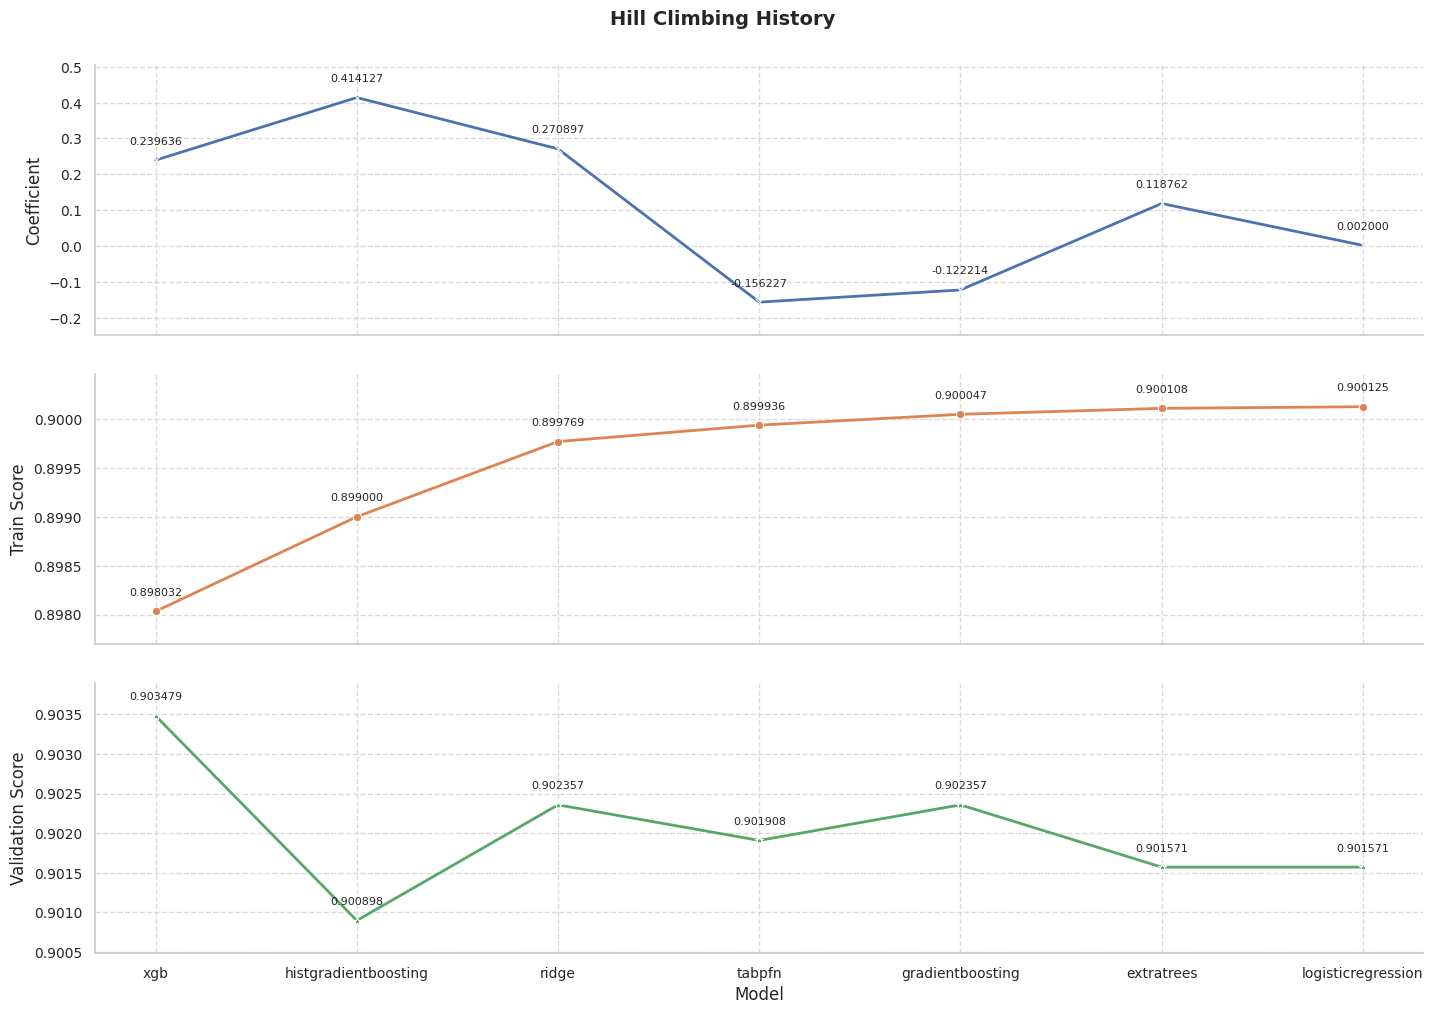

In [16]:
fold_1_history = climber_cv.history[climber_cv.history.fold == 1]

palette = sns.color_palette("deep")
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

sns.lineplot(x=fold_1_history.model[1:], y=fold_1_history.coef[1:], color=palette[0], marker='x', ax=ax1, linewidth=2)
add_annotations(ax1, fold_1_history.model[1:], fold_1_history.coef[1:])
ax1.set_ylabel('Coefficient', fontsize=12)
ax1.spines[['top', 'right']].set_visible(False)

sns.lineplot(x=fold_1_history.model[1:], y=fold_1_history.train_score[1:], color=palette[1], marker='o', ax=ax2, linewidth=2)
add_annotations(ax2, fold_1_history.model[1:], fold_1_history.train_score[1:])
ax2.set_ylabel('Train Score', fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)

sns.lineplot(x=fold_1_history.model[1:], y=fold_1_history.val_score[1:], color=palette[2], marker='*', ax=ax3, linewidth=2)
add_annotations(ax3, fold_1_history.model[1:], fold_1_history.val_score[1:])
ax3.set_ylabel('Validation Score', fontsize=12)
ax3.set_xlabel('Model', fontsize=12)
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig.suptitle('Hill Climbing History', y=1.02, fontsize=14, fontweight='bold')

for ax in [ax1, ax2, ax3]:
    ax.tick_params(labelsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.xaxis.grid(True, linestyle='--', alpha=0.7)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin - (ymax-ymin)*0.1, ymax + (ymax-ymin)*0.1)

plt.show()

## Predicting on the test set

In [17]:
preds = climber_cv.predict(X_test)
preds[:25]

array([ 0.96606967,  0.95883584,  0.8670834 ,  0.25055696,  0.18484295,
        0.82022868,  0.90631791,  0.94389199,  0.91918234,  0.71135818,
        0.96084577,  0.18178649,  0.95951116,  0.89159637,  0.26445588,
       -0.00603268,  0.85007232,  0.67606721,  0.16715454,  0.01479453,
        0.18865975,  0.23264355,  0.64884886,  0.98020263,  0.77033949])

# Results

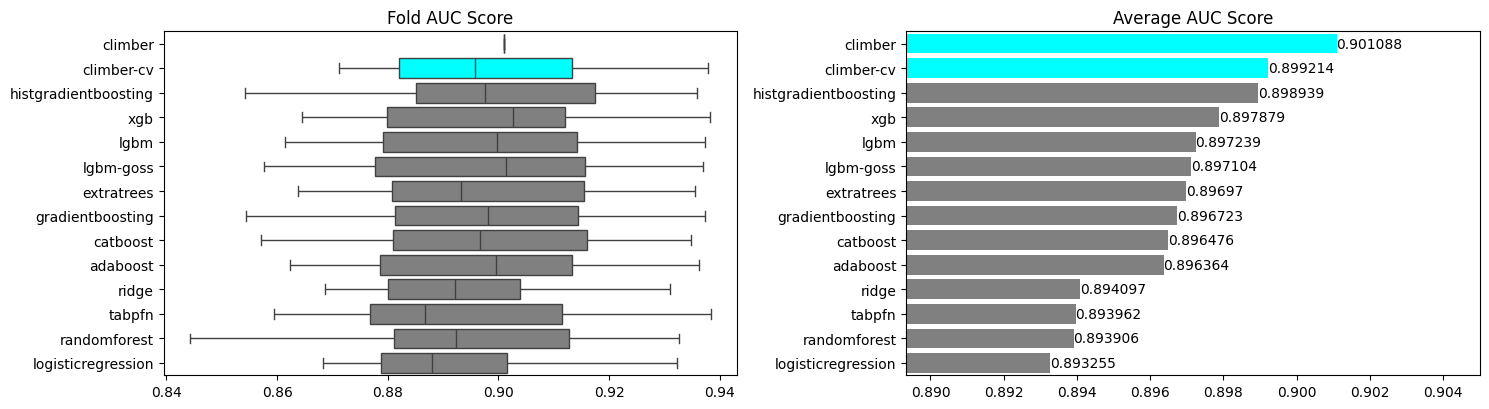

In [18]:
sns.reset_defaults()

scores = pd.DataFrame(scores)
mean_scores = scores.mean().sort_values(ascending=False)
order = scores.mean().sort_values(ascending=False).index.tolist()

min_score = mean_scores.min()
max_score = mean_scores.max()
padding = (max_score - min_score) * 0.5
lower_limit = min_score - padding
upper_limit = max_score + padding

fig, axs = plt.subplots(1, 2, figsize=(15, scores.shape[1] * 0.3))

boxplot = sns.boxplot(data=scores, order=order, ax=axs[0], orient='h', color='grey')
axs[0].set_title('Fold AUC Score')
axs[0].set_xlabel('')
axs[0].set_ylabel('')

barplot = sns.barplot(x=mean_scores.values, y=mean_scores.index, ax=axs[1], color='grey')
axs[1].set_title('Average AUC Score')
axs[1].set_xlabel('')
axs[1].set_xlim(left=lower_limit, right=upper_limit)
axs[1].set_ylabel('')

for i, (score, model) in enumerate(zip(mean_scores.values, mean_scores.index)):
    color = 'cyan' if 'climber' in model.lower() else 'grey'
    barplot.patches[i].set_facecolor(color)
    boxplot.patches[i].set_facecolor(color)
    barplot.text(score, i, round(score, 6), va='center')

plt.tight_layout()
plt.show()